# Baselines and Coexistence

## Model-based baseline comparisons

### Holistic approach

Compare MORBO, qNParEGO, and the **random-threshold baseline** under RTS and STR. The setting is $\gamma_{\mathrm{sync}}=\gamma_{\mathrm{grav}}=\gamma_{\mathrm{heter}}=1$, with $M=40$ octopi, simulated rewards, and a horizon of **100 global iterations**. Reference costs are **(2,200,000 KiB, 310)**.

The original NSGA-II Pareto thresholds are reused. **20 sequences** are sampled independently; at every iteration, a threshold is selected uniformly with replacement from the distinct saved Pareto thresholds. Each sampled sequence is evaluated on the **same 10 held-out simulator seeds** used for the model-based solutions (200 new baseline simulations).

The bars measure the hypervolume of this **20-sequence comparison set**. They do not represent the hypervolume of a single policy obtained by averaging over all random sequences. MORBO/qNParEGO costs and solution sets are reused unchanged; no optimization was repeated.


#### Load the held-out evaluations

Load the original cache for the four model-based solution sets and the separate random-threshold baseline cache. The old constant-threshold measurements remain preserved but are not used for the current baseline bars. Executing this notebook only recalculates metrics and plots from saved costs.


In [1]:
from pathlib import Path
import hashlib
import importlib.util
import pickle
import sys

sys.dont_write_bytecode = True
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

roots = (Path.cwd(), *Path.cwd().parents)
project_root = next(
    (root for root in roots if (root / "Model-based baseline" / "evaluate_holistic_comparison.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Open this notebook from the Cosmic Octopi project.")
baselines = project_root / "Model-based baseline"
cache_path = baselines / "holistic hypervolume comparison.pkl"
if not cache_path.is_file():
    raise FileNotFoundError(
        'Run ".venv\\Scripts\\python.exe" -B "Model-based baseline\\evaluate_holistic_comparison.py" first.'
    )
with cache_path.open("rb") as file:
    evaluation = pickle.load(file)
if evaluation.get("kind") != "holistic_held_out_hypervolume_comparison" or not evaluation.get("complete"):
    raise ValueError("The held-out comparison is not complete yet.")
for filename, digest in evaluation["input_sha256"].items():
    if hashlib.sha256((baselines / filename).read_bytes()).hexdigest() != digest:
        raise ValueError(f"The evaluated Pareto set has changed: {filename}")
for relative, digest in evaluation["evaluation_source_sha256"].items():
    if hashlib.sha256((project_root / relative).read_bytes()).hexdigest() != digest:
        raise ValueError(f"The evaluation source has changed: {relative}")
sys.path.insert(0, str(baselines))
spec = importlib.util.spec_from_file_location(
    "_holistic_comparison_evaluation", baselines / "evaluate_holistic_comparison.py"
)
comparison = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = comparison
spec.loader.exec_module(comparison)
setup = evaluation["setup"]
settings = evaluation["evaluation_settings"]
costs = np.asarray(evaluation["cost_realizations"])
assert costs.shape == (
    len(evaluation["unit_sequences"]), settings["n_realizations_per_solution"], 2
)
assert np.isfinite(costs).all() and (costs >= 0).all()
assert len(set(evaluation["scenario_seeds"])) == settings["n_realizations_per_solution"]
random_module = importlib.import_module("evaluate_random_threshold_baseline")
random_path = baselines / "holistic random threshold baseline.pkl"
with random_path.open("rb") as file:
    random_evaluation = pickle.load(file)
assert random_evaluation["complete"] and random_evaluation["case"] == "holistic"
assert random_evaluation["kind"] == "random_pareto_threshold_sequence_evaluation"
random_module.check_sources(random_evaluation)
assert random_evaluation["setup"] == setup
assert random_evaluation["scenario_seeds"] == evaluation["scenario_seeds"]
assert random_evaluation["cost_realizations"].shape == (20, 10, 2)
assert np.isfinite(random_evaluation["cost_realizations"]).all()
display(Markdown("**Random-threshold baseline:** 20 sampled sequences x 10 shared realizations = **200 simulations**. Model-based evaluations are reused from the original cache."))


**Random-threshold baseline:** 20 sampled sequences x 10 shared realizations = **200 simulations**. Model-based evaluations are reused from the original cache.

#### Hypervolume definitions

Both objectives are minimized. Divide total overhead and total instability by the common fixed reference costs, **(2,200,000 KiB, 310)**, so the reference in normalized cost space is **(1, 1)**. All six bars use this same scale.

- **RTS:** average each solution's held-out cost realizations, then compute their standard dominated hypervolume. The two-dimensional area is computed exactly.
- **STR:** average the reference-based length scalarizations across realizations, then form their upper envelope across solutions. Integrate its squared length using the existing 128-direction midpoint rule.
- **Random threshold:** apply the same two definitions to the 20 sampled sequences, each with 10 measured cost realizations. RTS forms the exact hypervolume of the 20 mean-cost vectors. STR averages length scores over the 10 realizations of each sequence before taking the upper envelope across the 20 sequences. No Gaussian predictions or constant-threshold cost mixtures are used.

For $c_{ir}$, the cost vector of solution $i$ under realization $r$, $\eta$ the cost reference, and $w_j$ a positive unit direction:

$$
\ell_{ij}^{\mathrm{STR}}
=\frac{1}{R}\sum_{r=1}^{R}
\min_{d\in\{1,2\}}
\frac{\max(1-c_{ird}/\eta_d,0)}{w_{jd}},
\qquad
\widehat{\mathrm{HV}}_{\mathrm{STR}}
=\frac{\pi}{4J}\sum_{j=1}^{J}\left(\max_i\ell_{ij}^{\mathrm{STR}}\right)^2.
$$

The model-based results use **one optimization run per algorithm/formulation**; the baseline uses 20 random sequence candidates drawn from the previously identified threshold set. The ten evaluation realizations estimate stochastic costs; they are not ten independent optimization runs.


In [2]:
original_summary = comparison.comparison_statistics(evaluation)
np.testing.assert_allclose([row["hypervolume"] for row in original_summary],
                           [row["hypervolume"] for row in evaluation["summary"]], rtol=1e-12, atol=1e-14)
random_rows = random_module.baseline_statistics(random_evaluation)
np.testing.assert_allclose([row["hypervolume"] for row in random_rows],
                           [row["hypervolume"] for row in random_evaluation["summary"]], rtol=1e-12, atol=1e-14)
summary = []
for formulation in ("RTS", "STR"):
    for algorithm in ("MORBO", "qNParEGO"):
        summary.append(next(row for row in original_summary
                               if row["algorithm"] == algorithm and row["formulation"] == formulation))
    summary.append(next(row for row in random_rows if row["formulation"] == formulation))
assert len(summary) == 6
assert all(np.isfinite(row["hypervolume"]) and row["hypervolume"] >= 0 for row in summary)
table = ["| Method | Formulation | Evaluated sequences | Realizations per sequence | Hypervolume |",
         "|:--|:--|--:|--:|--:|"]
for row in summary:
    table.append(f"| {row['algorithm']} | {row['formulation']} | {row['n_solutions']} | {row['n_realizations']} | {row['hypervolume']:.6f} |")
display(Markdown("\n".join(table)))


C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


| Method | Formulation | Evaluated sequences | Realizations per sequence | Hypervolume |
|:--|:--|--:|--:|--:|
| MORBO | RTS | 8 | 10 | 0.651428 |
| qNParEGO | RTS | 6 | 10 | 0.639680 |
| Random threshold | RTS | 20 | 10 | 0.615491 |
| MORBO | STR | 8 | 10 | 0.665184 |
| qNParEGO | STR | 10 | 10 | 0.654468 |
| Random threshold | STR | 20 | 10 | 0.615182 |

#### Hypervolume comparison

Each formulation has three bars: MORBO, qNParEGO, and the random-threshold baseline (20 sequences). All use the same reference point and normalization within this case; the vertical axis starts at zero.


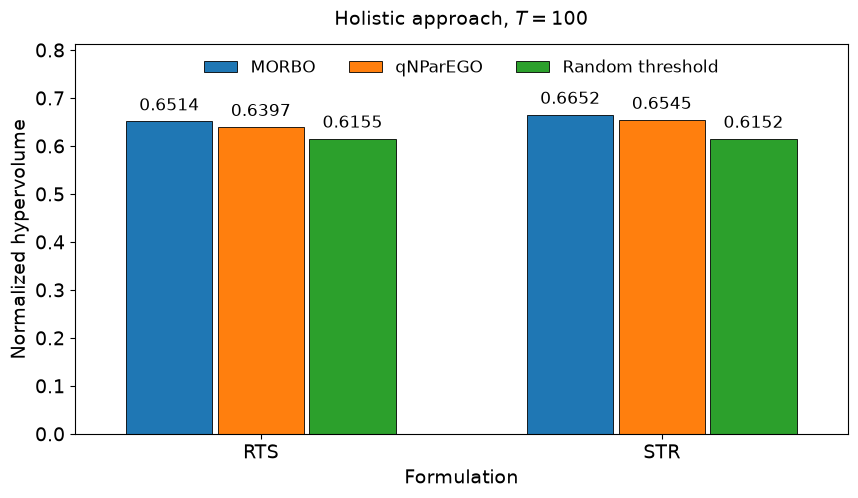

In [3]:
formulations = ("RTS", "STR")
algorithms = ("MORBO", "qNParEGO", "Random threshold")
colors = ("#1f77b4", "#ff7f0e", "#2ca02c")
centers = np.array([0.0, 1.4])
width = 0.32
lookup = {(row["algorithm"], row["formulation"]): row["hypervolume"] for row in summary}

with plt.rc_context({"font.size": 14, "svg.fonttype": "none"}):
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for index, (algorithm, color) in enumerate(zip(algorithms, colors)):
        values = [lookup[(algorithm, formulation)] for formulation in formulations]
        bars = ax.bar(centers + (index - 1) * width, values, width=width * 0.94,
                      color=color, edgecolor="black", linewidth=0.6, label=algorithm)
        ax.bar_label(bars, labels=[f"{value:.4f}" for value in values],
                     padding=5, fontsize=12)
    ax.set_xticks(centers, formulations)
    ax.set_xlabel("Formulation", fontsize=14)
    ax.set_ylabel("Normalized hypervolume", fontsize=14)
    ax.set_title(r"Holistic approach, $T=100$", fontsize=14, pad=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_ylim(0, max(0.05, max(lookup.values()) * 1.22))
    ax.set_xlim(-0.65, 2.05)
    ax.grid(False)
    ax.legend(loc="upper center", ncols=3, fontsize=12, frameon=False)
    fig.tight_layout()
    figure_base = project_root / "Paper plots" / "Holistic baseline comparison"
    fig.savefig(figure_base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(figure_base.with_suffix(".svg"), bbox_inches="tight")
    plt.show()


#### Reproducibility

The randomized-baseline cache stores the threshold sampling seed, threshold support, sampled indices, physical and normalized sequences, the 10 shared simulator seeds, and all 200 cost vectors. Its hashes identify the unchanged source Pareto set, original comparison cache, setup, and evaluator code. Both baseline bars use the same sampled sequences and measurements.

The following check compares exact RTS hypervolume with the 128-direction approximation. The original search outputs and constant-threshold evaluation caches are preserved.


In [4]:
rts_rows = [row for row in summary if row["formulation"] == "RTS"]
maximum_difference = max(
    abs(row["standard_hypervolume_of_means"] - row["rts_quadrature_hypervolume"])
    for row in rts_rows
)
display(Markdown(
    f"Maximum exact-versus-quadrature RTS difference: **{maximum_difference:.6g}**.\n\n"
    f"Shared evaluation seeds: `{evaluation['scenario_seeds']}`."
))

display(Markdown("Threshold sampling seed: `" + str(random_evaluation["sampling_seed"]) + "`. Sequence array shape: `" + str(random_evaluation["physical_sequences"].shape) + "`."))


Maximum exact-versus-quadrature RTS difference: **6.04443e-05**.

Shared evaluation seeds: `[2385971528, 3193148690, 3937333334, 2534194614, 797263586, 823411603, 2233374801, 2779230037, 3961860411, 1056997447]`.

Threshold sampling seed: `20260916`. Sequence array shape: `(20, 100)`.

### Cheetah reductionist approach

Compare MORBO, qNParEGO, and the **random-threshold baseline** under RTS and STR. The setting is $\gamma_{\mathrm{sync}}=\gamma_{\mathrm{grav}}=\gamma_{\mathrm{heter}}=1$, with $M=40$ octopi, simulated rewards, and a horizon of **50 Cheetah requests**. Reference costs are **(90,497.578125 KiB, 85)**.

The original NSGA-II Pareto thresholds are reused. **20 sequences** are sampled independently; at every iteration, a threshold is selected uniformly with replacement from the distinct saved Pareto thresholds. Each sampled sequence is evaluated on the **same 10 held-out simulator seeds** used for the model-based solutions (200 new baseline simulations).

The bars measure the hypervolume of this **20-sequence comparison set**. They do not represent the hypervolume of a single policy obtained by averaging over all random sequences. MORBO/qNParEGO costs and solution sets are reused unchanged; no optimization was repeated.


#### Load the held-out evaluations

Load the original cache for the four model-based solution sets and the separate random-threshold baseline cache. The old constant-threshold measurements remain preserved but are not used for the current baseline bars. Executing this notebook only recalculates metrics and plots from saved costs.


In [5]:
from pathlib import Path
import hashlib
import importlib.util
import pickle
import sys
sys.dont_write_bytecode = True
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
roots = (Path.cwd(), *Path.cwd().parents)
project_root = next((root for root in roots if (root / 'Model-based baseline' / 'evaluate_reductionist_comparison.py').is_file()), None)
if project_root is None:
    raise FileNotFoundError('Open this notebook from the Cosmic Octopi project.')
baselines = project_root / 'Model-based baseline'
cache_path = baselines / 'reductionist hypervolume comparison.pkl'
if not cache_path.is_file():
    raise FileNotFoundError('Run ".venv\\Scripts\\python.exe" -B "Model-based baseline\\evaluate_reductionist_comparison.py" first.')
with cache_path.open('rb') as file:
    red_evaluation = pickle.load(file)
if red_evaluation.get('kind') != 'reductionist_held_out_hypervolume_comparison' or not red_evaluation.get('complete'):
    raise ValueError('The held-out comparison is not complete yet.')
for filename, digest in red_evaluation['input_sha256'].items():
    if hashlib.sha256((baselines / filename).read_bytes()).hexdigest() != digest:
        raise ValueError(f'The evaluated Pareto set has changed: {filename}')
for relative, digest in red_evaluation['evaluation_source_sha256'].items():
    if hashlib.sha256((project_root / relative).read_bytes()).hexdigest() != digest:
        raise ValueError(f'The evaluation source has changed: {relative}')
sys.path.insert(0, str(baselines))
spec = importlib.util.spec_from_file_location('_reductionist_comparison_evaluation', baselines / 'evaluate_reductionist_comparison.py')
red_comparison = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = red_comparison
spec.loader.exec_module(red_comparison)
red_setup = red_evaluation['setup']
red_settings = red_evaluation['evaluation_settings']
red_costs = np.asarray(red_evaluation['cost_realizations'])
assert red_costs.shape == (len(red_evaluation['unit_sequences']), red_settings['n_realizations_per_solution'], 2)
assert np.isfinite(red_costs).all() and (red_costs >= 0).all()
assert len(set(red_evaluation['scenario_seeds'])) == red_settings['n_realizations_per_solution']
random_module = importlib.import_module("evaluate_random_threshold_baseline")
random_path = baselines / "reductionist random threshold baseline.pkl"
with random_path.open("rb") as file:
    red_random_evaluation = pickle.load(file)
assert red_random_evaluation["complete"] and red_random_evaluation["case"] == "reductionist"
assert red_random_evaluation["kind"] == "random_pareto_threshold_sequence_evaluation"
random_module.check_sources(red_random_evaluation)
assert red_random_evaluation["setup"] == red_setup
assert red_random_evaluation["scenario_seeds"] == red_evaluation["scenario_seeds"]
assert red_random_evaluation["cost_realizations"].shape == (20, 10, 2)
assert np.isfinite(red_random_evaluation["cost_realizations"]).all()
display(Markdown("**Random-threshold baseline:** 20 sampled sequences x 10 shared realizations = **200 simulations**. Model-based evaluations are reused from the original cache."))


**Random-threshold baseline:** 20 sampled sequences x 10 shared realizations = **200 simulations**. Model-based evaluations are reused from the original cache.

#### Hypervolume definitions

Both objectives are minimized. Divide total overhead and total instability by the common fixed reference costs, **(90,497.578125 KiB, 85)**, so the reference in normalized cost space is **(1, 1)**. All six bars use this same scale.

- **RTS:** average each solution's held-out cost realizations, then compute their standard dominated hypervolume. The two-dimensional area is computed exactly.
- **STR:** average the reference-based length scalarizations across realizations, then form their upper envelope across solutions. Integrate its squared length using the existing 128-direction midpoint rule.
- **Random threshold:** apply the same two definitions to the 20 sampled sequences, each with 10 measured cost realizations. RTS forms the exact hypervolume of the 20 mean-cost vectors. STR averages length scores over the 10 realizations of each sequence before taking the upper envelope across the 20 sequences. No Gaussian predictions or constant-threshold cost mixtures are used.

For $c_{ir}$, the cost vector of solution $i$ under realization $r$, $\eta$ the cost reference, and $w_j$ a positive unit direction:

$$
\ell_{ij}^{\mathrm{STR}}
=\frac{1}{R}\sum_{r=1}^{R}
\min_{d\in\{1,2\}}
\frac{\max(1-c_{ird}/\eta_d,0)}{w_{jd}},
\qquad
\widehat{\mathrm{HV}}_{\mathrm{STR}}
=\frac{\pi}{4J}\sum_{j=1}^{J}\left(\max_i\ell_{ij}^{\mathrm{STR}}\right)^2.
$$

The model-based results use **one optimization run per algorithm/formulation**; the baseline uses 20 random sequence candidates drawn from the previously identified threshold set. The ten evaluation realizations estimate stochastic costs; they are not ten independent optimization runs.


In [6]:
red_original_summary = red_comparison.comparison_statistics(red_evaluation)
np.testing.assert_allclose([row["hypervolume"] for row in red_original_summary],
                           [row["hypervolume"] for row in red_evaluation["summary"]], rtol=1e-12, atol=1e-14)
red_random_rows = random_module.baseline_statistics(red_random_evaluation)
np.testing.assert_allclose([row["hypervolume"] for row in red_random_rows],
                           [row["hypervolume"] for row in red_random_evaluation["summary"]], rtol=1e-12, atol=1e-14)
red_summary = []
for formulation in ("RTS", "STR"):
    for algorithm in ("MORBO", "qNParEGO"):
        red_summary.append(next(row for row in red_original_summary
                               if row["algorithm"] == algorithm and row["formulation"] == formulation))
    red_summary.append(next(row for row in red_random_rows if row["formulation"] == formulation))
assert len(red_summary) == 6
assert all(np.isfinite(row["hypervolume"]) and row["hypervolume"] >= 0 for row in red_summary)
table = ["| Method | Formulation | Evaluated sequences | Realizations per sequence | Hypervolume |",
         "|:--|:--|--:|--:|--:|"]
for row in red_summary:
    table.append(f"| {row['algorithm']} | {row['formulation']} | {row['n_solutions']} | {row['n_realizations']} | {row['hypervolume']:.6f} |")
display(Markdown("\n".join(table)))


| Method | Formulation | Evaluated sequences | Realizations per sequence | Hypervolume |
|:--|:--|--:|--:|--:|
| MORBO | RTS | 12 | 10 | 0.550604 |
| qNParEGO | RTS | 16 | 10 | 0.584877 |
| Random threshold | RTS | 20 | 10 | 0.499175 |
| MORBO | STR | 7 | 10 | 0.540693 |
| qNParEGO | STR | 10 | 10 | 0.548024 |
| Random threshold | STR | 20 | 10 | 0.498774 |

#### Hypervolume comparison

Each formulation has three bars: MORBO, qNParEGO, and the random-threshold baseline (20 sequences). All use the same reference point and normalization within this case; the vertical axis starts at zero.


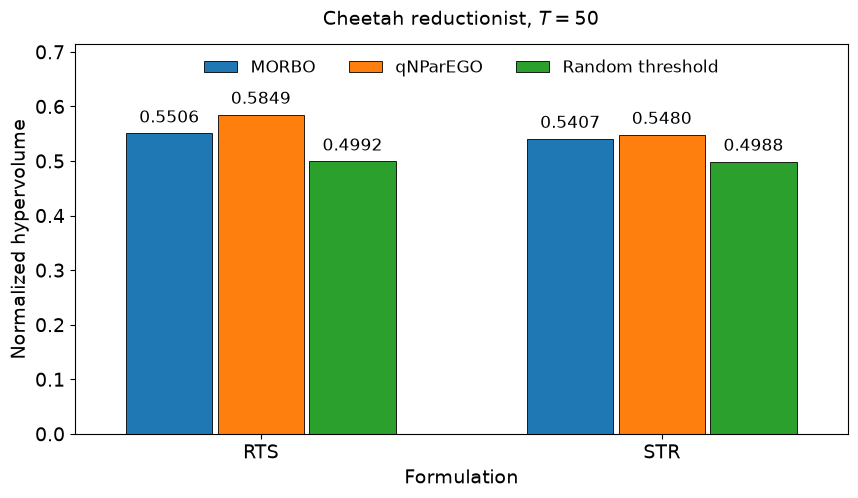

In [7]:
formulations = ('RTS', 'STR')
algorithms = ('MORBO', 'qNParEGO', 'Random threshold')
colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
centers = np.array([0.0, 1.4])
width = 0.32
lookup = {(row['algorithm'], row['formulation']): row['hypervolume'] for row in red_summary}
with plt.rc_context({'font.size': 14, 'svg.fonttype': 'none'}):
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for index, (algorithm, color) in enumerate(zip(algorithms, colors)):
        values = [lookup[algorithm, formulation] for formulation in formulations]
        bars = ax.bar(centers + (index - 1) * width, values, width=width * 0.94, color=color, edgecolor='black', linewidth=0.6, label=algorithm)
        ax.bar_label(bars, labels=[f'{value:.4f}' for value in values], padding=5, fontsize=12)
    ax.set_xticks(centers, formulations)
    ax.set_xlabel('Formulation', fontsize=14)
    ax.set_ylabel('Normalized hypervolume', fontsize=14)
    ax.set_title('Cheetah reductionist, $T=50$', fontsize=14, pad=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.set_ylim(0, max(0.05, max(lookup.values()) * 1.22))
    ax.set_xlim(-0.65, 2.05)
    ax.grid(False)
    ax.legend(loc='upper center', ncols=3, fontsize=12, frameon=False)
    fig.tight_layout()
    figure_base = project_root / 'Paper plots' / 'Reductionist baseline comparison'
    fig.savefig(figure_base.with_suffix('.png'), dpi=300, bbox_inches='tight')
    fig.savefig(figure_base.with_suffix('.svg'), bbox_inches='tight')
    plt.show()


#### Reproducibility

The randomized-baseline cache stores the threshold sampling seed, threshold support, sampled indices, physical and normalized sequences, the 10 shared simulator seeds, and all 200 cost vectors. Its hashes identify the unchanged source Pareto set, original comparison cache, setup, and evaluator code. Both baseline bars use the same sampled sequences and measurements.

The following check compares exact RTS hypervolume with the 128-direction approximation. The original search outputs and constant-threshold evaluation caches are preserved.


In [8]:
rts_rows = [row for row in red_summary if row['formulation'] == 'RTS']
maximum_difference = max((abs(row['standard_hypervolume_of_means'] - row['rts_quadrature_hypervolume']) for row in rts_rows))
display(Markdown(f"Maximum exact-versus-quadrature RTS difference: **{maximum_difference:.6g}**.\n\nShared evaluation seeds: `{red_evaluation['scenario_seeds']}`."))

display(Markdown("Threshold sampling seed: `" + str(red_random_evaluation["sampling_seed"]) + "`. Sequence array shape: `" + str(red_random_evaluation["physical_sequences"].shape) + "`."))


Maximum exact-versus-quadrature RTS difference: **7.14339e-05**.

Shared evaluation seeds: `[2385971528, 3193148690, 3937333334, 2534194614, 797263586, 823411603, 2233374801, 2779230037, 3961860411, 1056997447]`.

Threshold sampling seed: `20260917`. Sequence array shape: `(20, 50)`.

## Model-free baseline comparisons

### Holistic approach

Compare **Scalarized UCB**, **Scalarized KG**, and **Pareto UCB** under RTS and STR in the standard setting: $\gamma_{\mathrm{sync}}=\gamma_{\mathrm{grav}}=\gamma_{\mathrm{heter}}=1$, $M=40$ octopi, four classes, and simulated rewards.

All algorithms have **7 fitness-margin arms** and **150 online global iterations**. Scalarized UCB and KG use **7 scalarization directions** and retain their existing SPA definitions. Pareto UCB maximizes negative normalized costs using the notebook's mean-plus-confidence rule.

**Feedback differs by design:** UCB/KG use the current overhead and instability increments. Pareto UCB attributes $(\Delta O_t,\Delta I_{t+1})$ to the arm selected at global iteration $t$. This pair becomes available only after iteration $t+1$. Its final action remains pending, giving **149 completed observations** within the 150-iteration budget; no extra step or fabricated final instability is used.

Each final learned arm set supplies **20 common random sequence draws**, with a threshold drawn uniformly from that set at every iteration. Duplicate sequences are removed. Each sequence is evaluated over **100 global iterations** on the same **10 held-out seeds**. There is one training run per algorithm/formulation. Pareto UCB learns one set, which is evaluated under both RTS and STR.


#### Load the saved comparison

These cells load and score existing measurements. They do not run training or simulation. All experimental parameters and calibration matrices are embedded in `Model-free baseline/setup_model_free_holistic.json`.


In [9]:
from pathlib import Path
import hashlib
import importlib.util
import pickle
import sys
sys.dont_write_bytecode = True
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
mf_project_root = next((mf_root for mf_root in (Path.cwd(), *Path.cwd().parents) if (mf_root / 'Model-free baseline' / 'evaluate_holistic_comparison.py').is_file()))
mf_experiment_dir = mf_project_root / 'Model-free baseline'
sys.path.insert(0, str(mf_experiment_dir))
mf_spec = importlib.util.spec_from_file_location('_model_free_baseline_evaluation', mf_experiment_dir / 'evaluate_holistic_comparison.py')
mf_comparison = importlib.util.module_from_spec(mf_spec)
sys.modules[mf_spec.name] = mf_comparison
mf_spec.loader.exec_module(mf_comparison)
with (mf_experiment_dir / 'holistic hypervolume comparison.pkl').open('rb') as mf_file:
    mf_result = pickle.load(mf_file)
assert mf_result['complete'] and mf_result['kind'] == 'holistic_model_free_baseline_comparison'
mf_comparison.check_sources(mf_result)
mf_costs = np.asarray(mf_result['cost_realizations'])
assert mf_costs.shape == (len(mf_result['unit_sequences']), 10, 2)
assert np.isfinite(mf_costs).all() and (mf_costs >= 0).all()
display(Markdown(f'**Completed evaluation:** {mf_costs.shape[0]} unique sequences x {mf_costs.shape[1]} shared realizations = **{mf_costs.shape[0] * mf_costs.shape[1]:,} simulations**.'))


**Completed evaluation:** 100 unique sequences x 10 shared realizations = **1,000 simulations**.

#### Hypervolume definitions

Minimize total overhead and total instability, dividing by the fixed reference **(2,200,000 KiB, 310)**. The normalized reference is **(1, 1)** for all six bars.

- **RTS:** average each sequence's 10 cost realizations and compute the exact two-dimensional dominated area of the resulting mean-cost vectors.
- **STR:** average each sequence's reference-based length scores over those realizations, then take the upper envelope across sequences and integrate using the existing 128-direction midpoint rule.
- **Pareto UCB:** apply both definitions to its **same learned arm set, same sampled sequences, and same measured costs**. These are two evaluation formulations, not two Pareto UCB training variants.

These are finite sampled-set hypervolumes. The 20 sequence draws approximate the set of sequences available from the recommended arms; they are not 20 independent training runs or a single averaged random policy.


In [10]:
mf_summary = mf_comparison.statistics(mf_result)
np.testing.assert_allclose([mf_row['hypervolume'] for mf_row in mf_summary], [mf_row['hypervolume'] for mf_row in mf_result['summary']], rtol=1e-12, atol=1e-14)
assert len(mf_summary) == 6
mf_table = ['| Algorithm | Formulation | Recommended arm indices | Unique sequences | Realizations per sequence | Hypervolume |', '|:--|:--|:--|--:|--:|--:|']
for mf_row in mf_summary:
    mf_table.append(f"| {mf_row['algorithm']} | {mf_row['formulation']} | {mf_row['recommended_arm_indices'].tolist()} | {mf_row['n_solutions']} | {mf_row['n_realizations']} | {mf_row['hypervolume']:.6f} |")
display(Markdown('\n'.join(mf_table)))


| Algorithm | Formulation | Recommended arm indices | Unique sequences | Realizations per sequence | Hypervolume |
|:--|:--|:--|--:|--:|--:|
| Scalarized UCB | RTS | [0, 2, 4] | 20 | 10 | 0.589618 |
| Scalarized KG | RTS | [0, 1, 2, 3, 4] | 20 | 10 | 0.596447 |
| Pareto UCB | RTS | [0, 1, 2, 3, 4, 6] | 20 | 10 | 0.613905 |
| Scalarized UCB | STR | [0, 1, 4, 6] | 20 | 10 | 0.634191 |
| Scalarized KG | STR | [1, 2, 3, 4] | 20 | 10 | 0.617152 |
| Pareto UCB | STR | [0, 1, 2, 3, 4, 6] | 20 | 10 | 0.613296 |

#### Holistic hypervolume comparison

Three algorithms appear in each formulation group. The shared vertical axis starts at zero; higher hypervolume is better. Only Pareto UCB uses the explicitly requested next-iteration instability feedback.


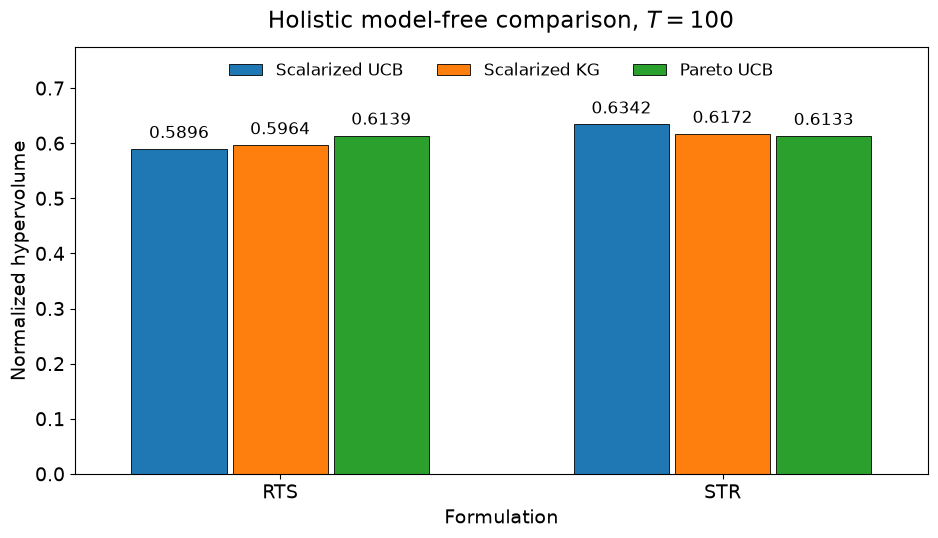

In [11]:
mf_formulations = ('RTS', 'STR')
mf_algorithms = ('Scalarized UCB', 'Scalarized KG', 'Pareto UCB')
mf_colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
mf_centers = np.array([0.0, 1.4])
mf_width = 0.32
mf_lookup = {(mf_row['algorithm'], mf_row['formulation']): mf_row['hypervolume'] for mf_row in mf_summary}
with plt.rc_context({'font.size': 14, 'svg.fonttype': 'none'}):
    mf_fig, mf_ax = plt.subplots(figsize=(9.6, 5.6))
    for mf_i, (mf_algorithm, mf_color) in enumerate(zip(mf_algorithms, mf_colors)):
        mf_values = [mf_lookup[mf_algorithm, mf_formulation] for mf_formulation in mf_formulations]
        mf_bars = mf_ax.bar(mf_centers + (mf_i - 1) * mf_width, mf_values, width=mf_width * 0.94, color=mf_color, edgecolor='black', linewidth=0.6, label=mf_algorithm)
        mf_ax.bar_label(mf_bars, labels=[f'{mf_value:.4f}' for mf_value in mf_values], padding=5, fontsize=12)
    mf_ax.set_xticks(mf_centers, mf_formulations)
    mf_ax.set_xlabel('Formulation')
    mf_ax.set_ylabel('Normalized hypervolume')
    mf_ax.set_title('Holistic model-free comparison, $T=100$', pad=14)
    mf_ax.set_ylim(0, max(0.05, max(mf_lookup.values()) * 1.22))
    mf_ax.set_xlim(-0.65, 2.05)
    mf_ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    mf_ax.grid(False)
    mf_ax.legend(loc='upper center', ncols=3, fontsize=12, frameon=False)
    mf_fig.tight_layout()
    mf_base = mf_project_root / 'Paper plots' / 'Holistic model-free baseline comparison'
    mf_fig.savefig(mf_base.with_suffix('.png'), dpi=300, bbox_inches='tight')
    mf_fig.savefig(mf_base.with_suffix('.svg'), bbox_inches='tight')
    plt.show()


#### Reproducibility and feedback check

The training files preserve every selected arm, current cost increments, and the final recommended set. Pareto UCB also stores each delayed observation's action and observation indices and the final pending action. The evaluation cache preserves all sampled sequences, seed lists, costs, and source/input hashes.


In [12]:
with (mf_experiment_dir / 'holistic Pareto UCB Pareto set.pkl').open('rb') as mf_file:
    mf_pareto = pickle.load(mf_file)
mf_training = mf_pareto['training']
mf_delayed = mf_training['delayed_observations']
mf_pairs = np.asarray([mf_row['costs'] for mf_row in mf_delayed])
np.testing.assert_allclose(mf_pairs[:, 0], mf_training['increment_costs'][:-1, 0])
np.testing.assert_allclose(mf_pairs[:, 1], mf_training['increment_costs'][1:, 1])
np.testing.assert_array_equal([mf_row['arm'] for mf_row in mf_delayed], mf_training['arm_history'][:-1])
assert len(mf_delayed) == 149 and mf_training['pending_final_action'][0] == 149
mf_rts_difference = max((abs(mf_row['exact_mean_cost_hypervolume'] - mf_row['quadrature_hypervolume']) for mf_row in mf_summary if mf_row['formulation'] == 'RTS'))
display(Markdown(f"Pareto UCB: **150 decisions, 149 completed delayed observations**, final action pending.\n\nMaximum exact-vs-quadrature RTS difference: **{mf_rts_difference:.6g}**.\n\nShared held-out seeds: `{mf_result['scenario_seeds']}`."))


Pareto UCB: **150 decisions, 149 completed delayed observations**, final action pending.

Maximum exact-vs-quadrature RTS difference: **1.35674e-05**.

Shared held-out seeds: `[2385971528, 3193148690, 3937333334, 2534194614, 797263586, 823411603, 2233374801, 2779230037, 3961860411, 1056997447]`.

### Cheetah reductionist approach

The same comparison is configured for **Cheetah**: $\gamma_{\mathrm{sync}}=\gamma_{\mathrm{grav}}=\gamma_{\mathrm{heter}}=1$, $M=40$, simulated rewards, **7 arms**, **7 scalarization directions**, and **150 Cheetah training requests**. The held-out horizon is **50 Cheetah requests**. The fixed reference costs are **(90,497.578125 KiB, 85)**, matching the existing reductionist comparisons.

Scalarized UCB and KG retain their current-request feedback. Only Pareto UCB pairs overhead at a Cheetah request with instability at the **next modeled Cheetah request**; its last action stays pending (149 observations for 150 decisions). Physical margins are used during simulation; normalized values are used for storage and sampling.

Each final arm set supplies **20 common random sequence draws**, deduplicated, with **10 shared held-out realizations per sequence**. Pareto UCB learns one set scored under both RTS and STR. These are single-training-run comparisons.

The reductionist simulations are complete. This section reads the saved results; no training or simulation is performed by the notebook.


#### Load reductionist results

Load the completed reductionist comparison cache and verify its input and source hashes. These cells only read saved results.


In [13]:
from pathlib import Path
import importlib.util
import pickle
import sys
sys.dont_write_bytecode = True
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
mf_red_root = next((mf_root for mf_root in (Path.cwd(), *Path.cwd().parents) if (mf_root / 'Model-free baseline' / 'evaluate_reductionist_comparison.py').is_file()))
mf_red_dir = mf_red_root / 'Model-free baseline'
mf_red_cache_path = mf_red_dir / 'reductionist hypervolume comparison.pkl'
mf_red_result = None
mf_red_summary = None
if not mf_red_cache_path.exists():
    display(Markdown('**Pending:** run the reductionist comparison command above, then rerun this section.'))
else:
    with mf_red_cache_path.open('rb') as mf_file:
        mf_red_loaded = pickle.load(mf_file)
    if not mf_red_loaded.get('complete'):
        display(Markdown('**Pending:** the reductionist evaluation is still incomplete. Rerun the command to resume it.'))
    else:
        sys.path.insert(0, str(mf_red_dir))
        mf_red_spec = importlib.util.spec_from_file_location('_reductionist_model_free_evaluation', mf_red_dir / 'evaluate_reductionist_comparison.py')
        mf_red_comparison = importlib.util.module_from_spec(mf_red_spec)
        sys.modules[mf_red_spec.name] = mf_red_comparison
        mf_red_spec.loader.exec_module(mf_red_comparison)
        assert mf_red_loaded['kind'] == 'reductionist_model_free_baseline_comparison'
        mf_red_comparison.check_sources(mf_red_loaded)
        mf_red_result = mf_red_loaded
        mf_red_costs = np.asarray(mf_red_result['cost_realizations'])
        assert np.isfinite(mf_red_costs).all() and (mf_red_costs >= 0).all()
        display(Markdown(f'**Completed reductionist evaluation:** {mf_red_costs.shape[0]} unique sequences x {mf_red_costs.shape[1]} shared realizations = **{mf_red_costs.shape[0] * mf_red_costs.shape[1]:,} simulations**.'))


**Completed reductionist evaluation:** 100 unique sequences x 10 shared realizations = **1,000 simulations**.

#### Reductionist hypervolumes

RTS uses exact 2D hypervolume of per-sequence mean costs; STR uses the existing 128-direction expected-length calculation. All costs are divided by the shared reference above. The same Pareto UCB sequence measurements are used for both formulations.


In [14]:
if mf_red_result is not None:
    mf_red_summary = mf_red_comparison.statistics(mf_red_result)
    np.testing.assert_allclose([mf_row['hypervolume'] for mf_row in mf_red_summary], [mf_row['hypervolume'] for mf_row in mf_red_result['summary']], rtol=1e-12, atol=1e-14)
    mf_red_table = ['| Algorithm | Formulation | Recommended arms | Unique sequences | Realizations | Hypervolume |', '|:--|:--|:--|--:|--:|--:|']
    for mf_row in mf_red_summary:
        mf_red_table.append(f"| {mf_row['algorithm']} | {mf_row['formulation']} | {mf_row['recommended_arm_indices'].tolist()} | {mf_row['n_solutions']} | {mf_row['n_realizations']} | {mf_row['hypervolume']:.6f} |")
    display(Markdown('\n'.join(mf_red_table)))


| Algorithm | Formulation | Recommended arms | Unique sequences | Realizations | Hypervolume |
|:--|:--|:--|--:|--:|--:|
| Scalarized UCB | RTS | [0, 2, 3, 4, 6] | 20 | 10 | 0.505501 |
| Scalarized KG | RTS | [0, 1, 2, 6] | 20 | 10 | 0.447376 |
| Pareto UCB | RTS | [0, 3, 5, 6] | 20 | 10 | 0.511617 |
| Scalarized UCB | STR | [0, 2, 3, 5, 6] | 20 | 10 | 0.503836 |
| Scalarized KG | STR | [0, 1, 2, 4, 6] | 20 | 10 | 0.470250 |
| Pareto UCB | STR | [0, 3, 5, 6] | 20 | 10 | 0.511276 |

#### Reductionist comparison plot

The six bars compare Scalarized UCB, Scalarized KG, and Pareto UCB under RTS and STR, using the same plot style as the holistic comparison.


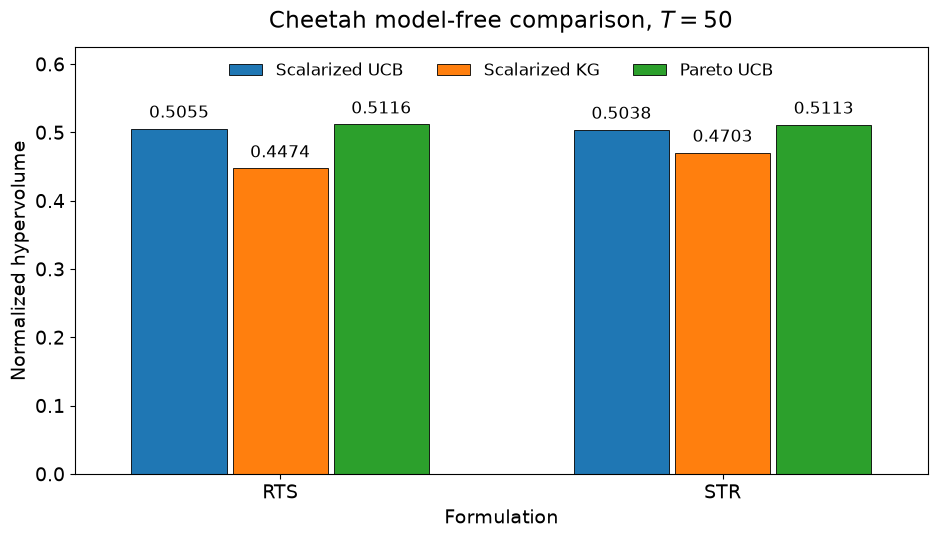

In [15]:
if mf_red_summary is not None:
    mf_red_formulations = ('RTS', 'STR')
    mf_red_algorithms = ('Scalarized UCB', 'Scalarized KG', 'Pareto UCB')
    mf_red_colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
    mf_red_centers = np.array([0.0, 1.4])
    mf_red_width = 0.32
    mf_red_lookup = {(mf_row['algorithm'], mf_row['formulation']): mf_row['hypervolume'] for mf_row in mf_red_summary}
    with plt.rc_context({'font.size': 14, 'svg.fonttype': 'none'}):
        mf_red_fig, mf_red_ax = plt.subplots(figsize=(9.6, 5.6))
        for mf_i, (mf_algorithm, mf_color) in enumerate(zip(mf_red_algorithms, mf_red_colors)):
            mf_values = [mf_red_lookup[mf_algorithm, mf_formulation] for mf_formulation in mf_red_formulations]
            mf_bars = mf_red_ax.bar(mf_red_centers + (mf_i - 1) * mf_red_width, mf_values, width=mf_red_width * 0.94, color=mf_color, edgecolor='black', linewidth=0.6, label=mf_algorithm)
            mf_red_ax.bar_label(mf_bars, labels=[f'{mf_value:.4f}' for mf_value in mf_values], padding=5, fontsize=12)
        mf_red_ax.set_xticks(mf_red_centers, mf_red_formulations)
        mf_red_ax.set_xlabel('Formulation')
        mf_red_ax.set_ylabel('Normalized hypervolume')
        mf_red_ax.set_title('Cheetah model-free comparison, $T=50$', pad=14)
        mf_red_ax.set_ylim(0, max(0.05, max(mf_red_lookup.values()) * 1.22))
        mf_red_ax.set_xlim(-0.65, 2.05)
        mf_red_ax.ticklabel_format(axis='y', style='plain', useOffset=False)
        mf_red_ax.grid(False)
        mf_red_ax.legend(loc='upper center', ncols=3, fontsize=12, frameon=False)
        mf_red_fig.tight_layout()
        mf_red_base = mf_red_root / 'Paper plots' / 'Reductionist model-free baseline comparison'
        mf_red_fig.savefig(mf_red_base.with_suffix('.png'), dpi=300, bbox_inches='tight')
        mf_red_fig.savefig(mf_red_base.with_suffix('.svg'), bbox_inches='tight')
        plt.show()


#### Reductionist feedback verification

Check physical arm values and verify the next-request instability pairing from the saved Pareto UCB training record. This check does not rerun the environment.


In [16]:
if mf_red_result is not None:
    with (mf_red_dir / 'reductionist Pareto UCB Pareto set.pkl').open('rb') as mf_file:
        mf_red_pareto = pickle.load(mf_file)
    mf_red_training = mf_red_pareto['training']
    mf_red_pairs = np.asarray([mf_row['costs'] for mf_row in mf_red_training['delayed_observations']])
    np.testing.assert_allclose(mf_red_pairs[:, 0], mf_red_training['increment_costs'][:-1, 0])
    np.testing.assert_allclose(mf_red_pairs[:, 1], mf_red_training['increment_costs'][1:, 1])
    np.testing.assert_array_equal([mf_row['arm'] for mf_row in mf_red_training['delayed_observations']], mf_red_training['arm_history'][:-1])
    assert len(mf_red_pairs) == 149 and mf_red_training['pending_final_action'][0] == 149
    np.testing.assert_allclose(mf_red_pareto['arms_physical'], -10 + 30 * mf_red_pareto['arms_unit'])
    display(Markdown('**Verified:** physical Cheetah margins and 149 delayed observations from 150 decisions.'))


**Verified:** physical Cheetah margins and 149 delayed observations from 150 decisions.

## final results

Quantization and SPA coexistence, using the completed simulations. Each figure has **RTS** and **STR** groups. Algorithm colors match the earlier plots. The solid lower segment shows the **standard hypervolume**, and the lighter hatched segment shows the **absolute gain from quantization**; the full bar height is the quantized hypervolume. Numbers above bars give the quantized total, and `+` labels give the gain.

The standard and quantized cases share reference costs and held-out seeds within each comparison. RTS uses exact hypervolume of mean costs; STR uses the saved expected-length estimate. These are single independent experiment results, with ten held-out realizations per solution. The model-based baseline samples a threshold from its learned Pareto set at every iteration (20 sampled sequences). No simulations are repeated here.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

final_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                   if (p / "Compression coexistence").is_dir()), None)
if final_root is None:
    raise FileNotFoundError("Open this notebook inside the Cosmic Octopi project.")

def final_read(path):
    with path.open("rb") as stream:
        result = pickle.load(stream)
    if not result.get("complete"):
        raise ValueError(f"Incomplete result: {path.name}")
    return result

final_cases = {}
for final_family in ("model-based", "model-free"):
    for final_approach in ("holistic", "reductionist"):
        final_suffix = " model-based" if final_family == "model-based" else ""
        final_result = final_read(final_root / "Compression coexistence" /
                                 f"{final_approach}{final_suffix} hypervolume comparison quantized.pkl")
        final_standard = final_read(final_root / f"{final_family.capitalize()} baseline" /
                                   f"{final_approach} hypervolume comparison.pkl")
        final_standard_rows = list(final_standard["summary"])
        if final_family == "model-based":
            final_random = final_read(final_root / "Model-based baseline" /
                                      f"{final_approach} random threshold baseline.pkl")
            final_standard_rows += final_random["summary"]
            assert final_random["scenario_seeds"] == final_standard["scenario_seeds"]
        assert final_result["scenario_seeds"] == final_standard["scenario_seeds"]
        np.testing.assert_array_equal(final_result["setup"]["reference_costs"],
                                      final_standard["setup"]["reference_costs"])
        final_old_lookup = {(r["algorithm"], r["formulation"]): r["hypervolume"]
                            for r in final_standard_rows}
        final_new_lookup = {(r["algorithm"], r["formulation"]): r["hypervolume"]
                            for r in final_result["summary"]}
        final_algorithms = (("MORBO", "qNParEGO", "Random threshold") if final_family == "model-based"
                            else ("Scalarized UCB", "Scalarized KG", "Pareto UCB"))
        final_rows = final_result["standard_comparison"]
        assert len(final_rows) == 6
        assert {(r["algorithm"], r["formulation"]) for r in final_rows} == {
            (a, f) for a in final_algorithms for f in ("RTS", "STR")}
        for final_row in final_rows:
            final_key = (final_row["algorithm"], final_row["formulation"])
            np.testing.assert_allclose(final_row["standard_hypervolume"], final_old_lookup[final_key], rtol=1e-12)
            np.testing.assert_allclose(final_row["quantized_hypervolume"], final_new_lookup[final_key], rtol=1e-12)
            np.testing.assert_allclose(final_row["difference"],
                final_new_lookup[final_key] - final_old_lookup[final_key], rtol=1e-12, atol=1e-14)
            if not np.isfinite(list(final_new_lookup.values())).all() or final_row["difference"] < 0:
                raise ValueError("This gain-stack plot requires finite hypervolumes and nonnegative gains.")
        final_cases[final_family, final_approach] = (final_result, final_algorithms)

def final_plot(family, approach):
    result, algorithms = final_cases[family, approach]
    lookup = {(r["algorithm"], r["formulation"]): r for r in result["standard_comparison"]}
    colors = ("#1f77b4", "#ff7f0e", "#2ca02c")
    centers, width = np.array([0.0, 1.4]), 0.32
    formulations = ("RTS", "STR")
    horizon = result["setup"][approach]["horizon"]
    approach_label = "Holistic" if approach == "holistic" else "Cheetah reductionist"
    with plt.rc_context({"font.size": 14, "svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(9.6, 5.8))
        for index, (algorithm, color) in enumerate(zip(algorithms, colors)):
            standard = np.array([lookup[algorithm, f]["standard_hypervolume"] for f in formulations])
            gains = np.array([lookup[algorithm, f]["difference"] for f in formulations])
            total = standard + gains
            positions = centers + (index - 1) * width
            light = tuple(.68 + .32 * np.array(to_rgb(color)))
            ax.bar(positions, standard, width=width*.94, color=color, edgecolor="black", linewidth=.6)
            upper = ax.bar(positions, gains, bottom=standard, width=width*.94,
                           color=light, edgecolor="black", linewidth=.6, hatch="///")
            ax.bar_label(upper, labels=[f"{value:.3f}" for value in total], padding=5, fontsize=11)
            for x, base, gain in zip(positions, standard, gains):
                ax.text(x, base*.5, f"{base:.3f}", ha="center", va="center", fontsize=11,
                        color="white" if index == 0 else "black")
                ax.text(x, base+gain*.5, f"+{gain:.3f}", ha="center", va="center", fontsize=9,
                        bbox={"facecolor": light, "edgecolor": "none", "pad": .3})
        ax.set_xticks(centers, formulations)
        ax.set_xlabel("Formulation")
        ax.set_ylabel("Normalized hypervolume")
        ax.set_title(f"{approach_label} {family} comparison, $T={horizon}$", pad=14)
        ax.set_ylim(0, 1.03)
        ax.set_xlim(-.65, 2.05)
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
        ax.grid(False)
        algorithm_legend = ax.legend(handles=[Patch(facecolor=c, edgecolor="black", linewidth=.6, label=a)
                                              for a, c in zip(algorithms, colors)],
                                     loc="upper center", ncols=3, fontsize=11, frameon=False)
        ax.add_artist(algorithm_legend)
        ax.legend(handles=[Patch(facecolor="0.55", edgecolor="black", label="Standard"),
                           Patch(facecolor="0.92", edgecolor="black", hatch="///", label="Quantization gain")],
                  loc="upper center", bbox_to_anchor=(.5, .93), ncols=2, fontsize=11, frameon=False)
        fig.tight_layout()
        output = final_root / "Paper plots" / f"Final results {family} {approach}"
        fig.savefig(output.with_suffix(".png"), dpi=300, bbox_inches="tight")
        fig.savefig(output.with_suffix(".svg"), bbox_inches="tight")
        plt.show()


### Model-based holistic

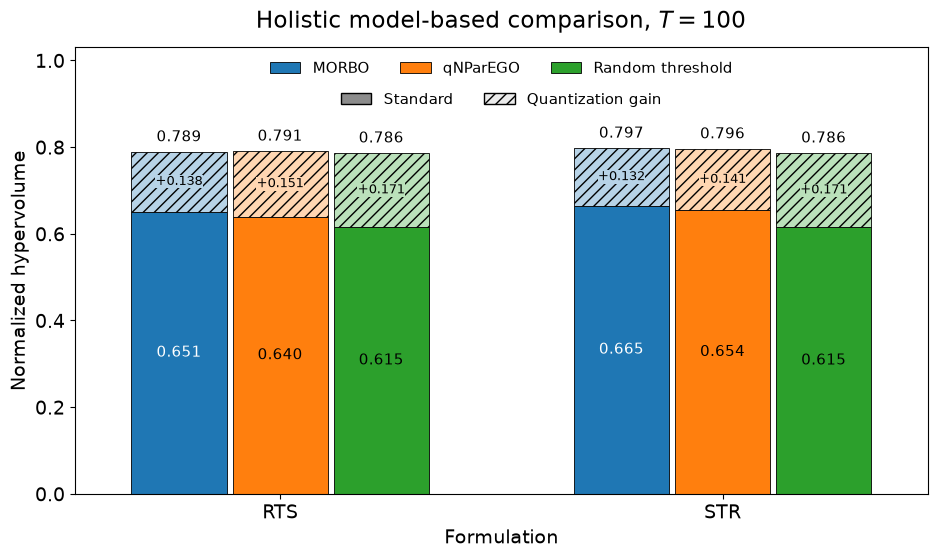

In [2]:
final_plot("model-based", "holistic")

### Model-based reductionist

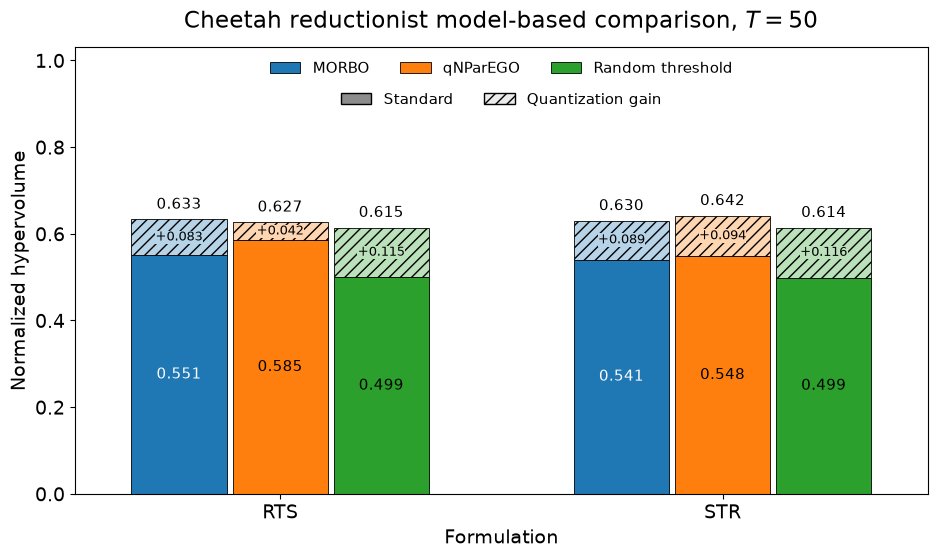

In [3]:
final_plot("model-based", "reductionist")

### Model-free holistic

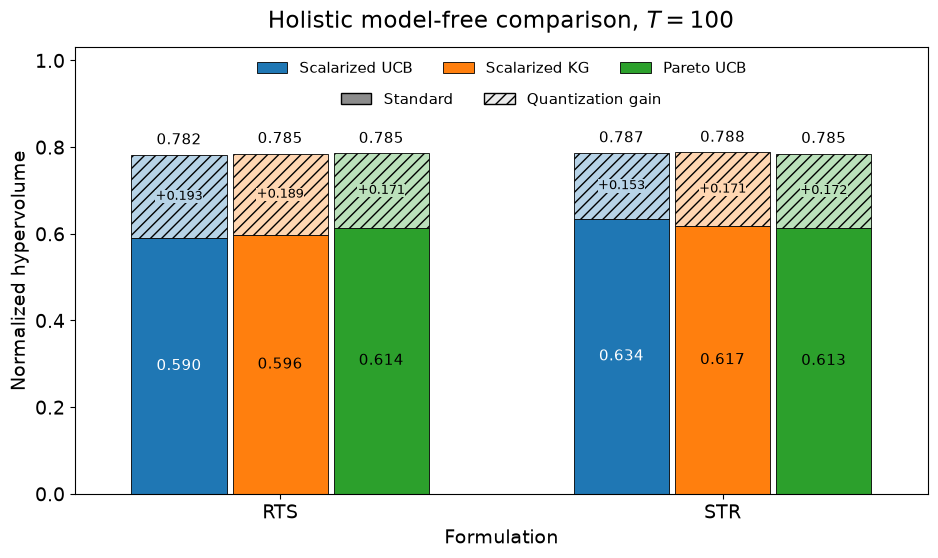

In [4]:
final_plot("model-free", "holistic")

### Model-free reductionist

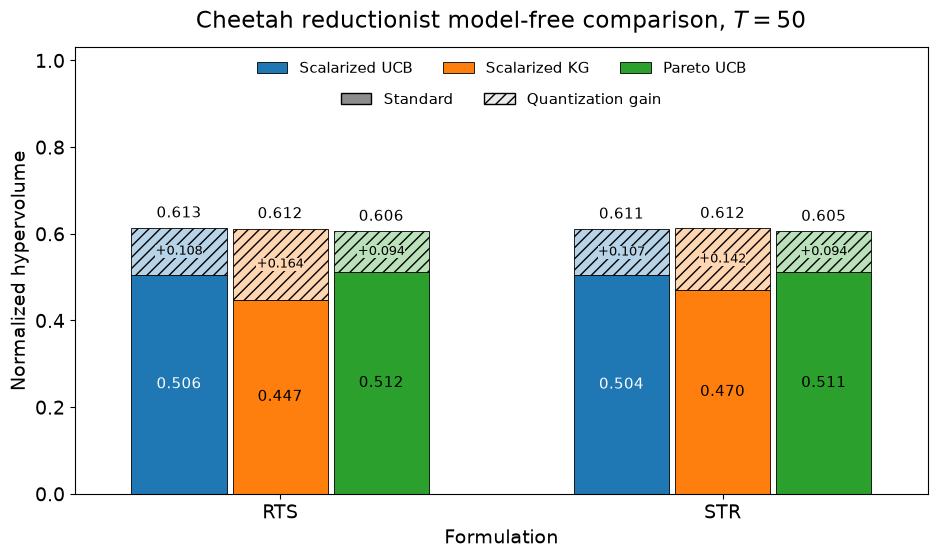

In [5]:
final_plot("model-free", "reductionist")